In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.shape

(569, 31)

In [5]:
data.DESCR

'.. _breast_cancer_dataset:\n\nBreast cancer wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [6]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
columns = data.feature_names

X_train = pd.DataFrame(X_train, columns = columns)
X_test = pd.DataFrame(X_test, columns = columns)

X_train.tail(7)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
419,0.550843,0.341673,0.643518,0.388531,1.475571,1.854330,1.015586,1.380805,1.234300,1.487172,...,0.952884,0.968902,0.857667,0.744287,2.067681,1.100615,0.991843,1.415374,1.231537,1.726732
420,-0.159282,-1.291909,-0.138679,-0.265658,0.613080,0.273753,-0.137404,-0.115993,0.508492,0.006631,...,-0.262385,-1.418951,-0.184130,-0.339633,0.219706,0.103462,-0.071442,-0.360406,0.231261,-0.127814
421,1.194654,-0.178760,1.164716,1.149318,0.152119,0.009054,0.538869,0.999480,1.119321,-0.388462,...,1.353231,0.336579,1.307070,1.241056,0.318145,-0.292152,0.207989,0.757847,1.214372,0.102075
422,0.086637,0.230840,0.097864,-0.041443,0.150670,0.300413,0.347936,0.276631,0.465375,0.235812,...,0.418409,0.742597,0.306127,0.276842,1.007221,0.985634,1.080009,1.056862,2.865374,0.989031
423,0.979129,0.356129,1.016375,0.842744,1.076941,1.174491,1.179419,1.447569,0.540830,-0.185994,...,0.853305,-0.091071,0.743857,0.721864,0.407636,0.623151,0.413227,0.564098,-0.708156,-0.378861
424,-0.236650,-1.335278,-0.250937,-0.319370,-0.943026,-0.363239,-0.480221,-0.523511,-0.731130,-0.990239,...,-0.412769,-1.379014,-0.315741,-0.448129,-0.719942,0.095017,0.067792,-0.347744,-0.282142,-0.617899
425,-0.692567,2.416177,-0.688743,-0.668363,-0.222593,-0.363429,-0.223632,-0.741008,-0.077184,-0.185994,...,-0.640378,2.188621,-0.623611,-0.613546,0.353941,-0.329829,0.095253,-0.704425,-0.051189,-0.675085


In [12]:
# PCA yapmadan sınıflandırma

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [13]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [14]:
logistic.fit(X_train, y_train)

LogisticRegression()

In [17]:
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression\n")
y_pred = logistic.predict(X_test)

print(classification_report(y_test, y_pred), "\n")
print(confusion_matrix(y_test, y_pred))
print("-" * 50, "\n")

print("Gradient Boosting Classifier\n")
y_pred = gbc.predict(X_test)

print(classification_report(y_test, y_pred), "\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143
 

[[49  4]
 [ 2 88]]
-------------------------------------------------- 

Gradient Boosting Classifier

              precision    recall  f1-score   support

           0       0.98      0.87      0.92        53
           1       0.93      0.99      0.96        90

    accuracy                           0.94       143
   macro avg       0.95      0.93      0.94       143
weighted avg       0.95      0.94      0.94       143
 

[[46  7]
 [ 1 89]]


In [39]:
# PCA

from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components=4)

In [41]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [42]:
X_train_pca = pd.DataFrame(X_train_pca, columns = ["PC 1", "PC 2", "PC 3", "PC 4"])
X_test_pca = pd.DataFrame(X_test_pca, columns = ["PC 1", "PC 2", "PC 3", "PC 4"])

X_test_pca.head(10)

,PC 1,PC 2,PC 3,PC 4
0,-4.055084,-1.442788,0.641033,-0.710474
1,-2.975967,1.721797,-0.273579,-0.480817
2,1.256723,-1.240024,0.523116,-0.544680
3,-1.611867,-1.127494,-1.231901,-0.650495
4,-2.105255,1.739708,-0.561954,0.419163
5,5.018798,0.928758,2.470358,1.738368
6,-3.320482,-3.190816,0.361913,-0.629554
7,-3.147649,-1.951265,-0.508048,-0.279509
8,-1.208409,-1.478101,-0.390395,-2.012054
9,-4.112005,-1.420987,0.950948,0.141159


In [43]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [44]:
logistic.fit(X_train_pca, y_train)
gbc.fit(X_train_pca, y_train)

GradientBoostingClassifier()

In [45]:
print("------- AFTER PCA -------\n")

print("Logistic Regression\n")
y_pred = logistic.predict(X_test_pca)

print(classification_report(y_test, y_pred), "\n")
print(confusion_matrix(y_test, y_pred))
print("-" * 50, "\n")

print("Gradient Boosting Classifier\n")
y_pred = gbc.predict(X_test_pca)

print(classification_report(y_test, y_pred), "\n")
print(confusion_matrix(y_test, y_pred))

------- AFTER PCA -------

Logistic Regression

              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143
 

[[48  5]
 [ 4 86]]
-------------------------------------------------- 

Gradient Boosting Classifier

              precision    recall  f1-score   support

           0       0.87      0.91      0.89        53
           1       0.94      0.92      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143
 

[[48  5]
 [ 7 83]]


In [46]:
# Görsellştirme

X = df.drop("target", axis = 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [49]:
pca = PCA(n_components=2)
X = pca.fit_transform(X)

X = pd.DataFrame(X, columns = ["PC1", "PC2"])

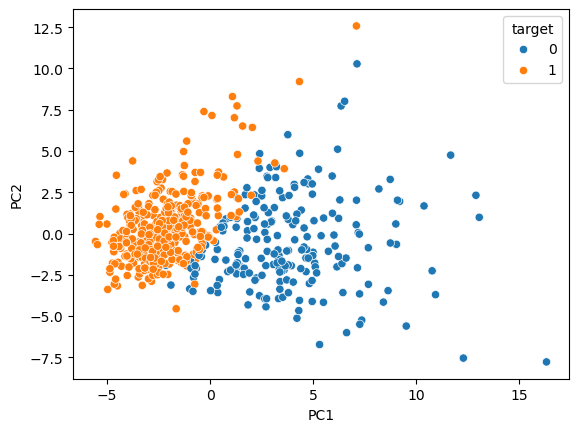

In [52]:
sns.scatterplot(data = X, x = "PC1", y = "PC2", hue = df["target"])
plt.show()

# 30 özellikli veriyi doğrudan görmek zor olduğu için PCA ile boyutu 2’ye indirdik.
# Bu sayede veriyi PC1 ve PC2 eksenlerinde görselleştirip, sınıflar arasındaki ayrımı daha net şekilde gözlemleyebiliyoruz.